In [136]:
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gdp
import numpy as np
import seaborn as sns
from sklearn.cluster import DBSCAN

In [137]:
df = pd.read_parquet("../data/clean2.parquet")
df.head()

,crash date,crash time,borough,zip code,latitude,longitude,location,on street name,cross street name,off street name,...,contributing factor vehicle 5,collision_id,vehicle type code 1,vehicle type code 2,vehicle type code 3,vehicle type code 4,vehicle type code 5,month,hour_of_collision,time_period
0,2020-08-29,1900-01-01 15:40:00,bronx,10466.0,40.89210,-73.833760,point (-73.83376 40.8921),pratt avenue,strang avenue,NaN,...,NaN,4342908,sedan,station wagon/sport utility vehicle,NaN,NaN,NaN,august,15,afternoon
1,2020-08-29,1900-01-01 21:00:00,brooklyn,11221.0,40.69050,-73.919914,point (-73.919914 40.6905),bushwick avenue,palmetto street,NaN,...,NaN,4343555,sedan,sedan,NaN,NaN,NaN,august,21,evening
2,2020-08-29,1900-01-01 18:20:00,manhattan,NaN,40.81650,-73.946556,point (-73.946556 40.8165),8 avenue,NaN,NaN,...,NaN,4343142,station wagon/sport utility vehicle,NaN,NaN,NaN,NaN,august,18,evening
3,2020-08-29,1900-01-01 00:00:00,bronx,10459.0,40.82472,-73.892960,point (-73.89296 40.82472),NaN,NaN,1047 simpson street,...,NaN,4343588,station wagon/sport utility vehicle,station wagon/sport utility vehicle,sedan,motorcycle,NaN,august,0,night
4,2020-08-29,1900-01-01 17:10:00,brooklyn,11203.0,40.64989,-73.933890,point (-73.93389 40.64989),NaN,NaN,4609 snyder avenue,...,NaN,4342953,sedan,sedan,NaN,NaN,NaN,august,17,afternoon


In [138]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 74881 entries, 0 to 74880
Data columns (total 32 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   crash date                     74881 non-null  datetime64[us]
 1   crash time                     74881 non-null  datetime64[us]
 2   borough                        70316 non-null  str           
 3   zip code                       49134 non-null  float64       
 4   latitude                       68935 non-null  float64       
 5   longitude                      68935 non-null  float64       
 6   location                       68935 non-null  str           
 7   on street name                 55444 non-null  str           
 8   cross street name              35681 non-null  str           
 9   off street name                19437 non-null  str           
 10  number of persons injured      74881 non-null  int64         
 11  number of persons killed  

In [139]:
df.columns

Index(['crash date', 'crash time', 'borough', 'zip code', 'latitude',
       'longitude', 'location', 'on street name', 'cross street name',
       'off street name', 'number of persons injured',
       'number of persons killed', 'number of pedestrians injured',
       'number of pedestrians killed', 'number of cyclist injured',
       'number of cyclist killed', 'number of motorist injured',
       'number of motorist killed', 'contributing factor vehicle 1',
       'contributing factor vehicle 2', 'contributing factor vehicle 3',
       'contributing factor vehicle 4', 'contributing factor vehicle 5',
       'collision_id', 'vehicle type code 1', 'vehicle type code 2',
       'vehicle type code 3', 'vehicle type code 4', 'vehicle type code 5',
       'month', 'hour_of_collision', 'time_period'],
      dtype='str')

In [140]:
# identifying accidents hotspots
# first is determining what we should set as hotspots 

In [141]:
#what are all the boroughs in our datasets
df["borough"].unique()

<ArrowStringArray>
['bronx', 'brooklyn', 'manhattan', 'queens', nan, 'staten island']
Length: 6, dtype: str

In [142]:
df["borough"].count() - df["crash date"].count()

np.int64(-4565)

In [143]:
df["on street name"].count() / df["crash date"].count()  * 100

np.float64(74.042814599164)

In [144]:
df["number of persons killed"].sum()

np.int64(144)

In [145]:
month_order = ['january','february','march','april','may','june','july','august']
hour = list(range(0,24))

In [146]:
borough_analysis = df.groupby(["borough"]).agg(
    crashes = ("collision_id","count"),
    people_killed = ("number of persons killed","sum"),
    people_injured = ("number of persons injured","sum")
).reset_index().sort_values(by="crashes",ascending=False)
borough_analysis

,borough,crashes,people_killed,people_injured
1,brooklyn,22716,38,8527
3,queens,20482,43,7355
0,bronx,13309,24,5011
2,manhattan,11229,17,3497
4,staten island,2580,8,1087


In [147]:
borough_month_analysis = df.groupby(["borough","month"]).agg(
    crashes = ("collision_id","count"),
    people_killed = ("number of persons killed","sum"),
    people_injured = ("number of persons injured","sum")
).reset_index().sort_values(by="crashes",ascending=False)
borough_month_analysis["month"] = pd.Categorical(borough_month_analysis["month"], categories=month_order, ordered=True)
borough_month_analysis = borough_month_analysis.sort_values(by=["month"])
borough_month_analysis

,borough,month,crashes,people_killed,people_injured
27,queens,january,4183,7,1241
11,brooklyn,january,4144,8,1258
19,manhattan,january,2269,1,483
35,staten island,january,419,1,182
3,bronx,january,2405,1,776
10,brooklyn,february,3984,5,1178
26,queens,february,3859,4,1106
2,bronx,february,2215,4,737
18,manhattan,february,2381,5,552
34,staten island,february,364,1,163


In [148]:
borough_analysis_pivot = borough_month_analysis.pivot(index="month",columns="borough",values="crashes").reset_index()
borough_analysis_pivot

borough,month,bronx,brooklyn,manhattan,queens,staten island
0,january,2405,4144,2269,4183,419
1,february,2215,3984,2381,3859,364
2,march,1849,3373,1806,3052,333
3,april,827,1251,510,1080,203
4,may,1206,1924,788,1595,272
5,june,1447,2407,1018,1977,281
6,july,1696,2917,1263,2437,337
7,august,1664,2716,1194,2299,371


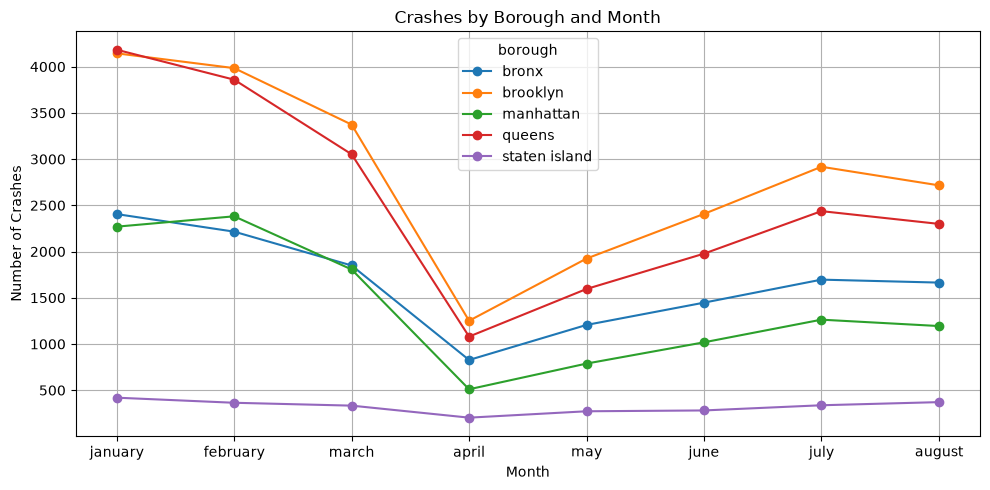

In [149]:
borough_analysis_pivot.plot(figsize=(10,5),marker="o",x="month")
plt.title("Crashes by Borough and Month")
plt.xlabel("Month")
plt.ylabel("Number of Crashes") 
plt.ticklabel_format(style='plain', axis='y')
plt.grid(True)
plt.tight_layout()
plt.show()

In [150]:
borough_hourly_analysis = df.groupby(["borough","hour_of_collision"]).agg(
    crashes = ("collision_id","count"), 
).reset_index().sort_values(by="crashes",ascending=False)
borough_hourly_analysis["hour_of_collision"] = pd.Categorical(borough_hourly_analysis["hour_of_collision"], categories=hour, ordered=True)
borough_hourly_analysis

,borough,hour_of_collision,crashes
40,brooklyn,16,1664
41,brooklyn,17,1528
38,brooklyn,14,1501
42,brooklyn,18,1490
37,brooklyn,13,1408
...,...,...,...
97,staten island,1,46
101,staten island,5,42
99,staten island,3,38
100,staten island,4,30


In [151]:
borough_hourly_analysis_pivot = borough_hourly_analysis.pivot(index="hour_of_collision",columns="borough",values="crashes").reset_index()
borough_hourly_analysis_pivot

borough,hour_of_collision,bronx,brooklyn,manhattan,queens,staten island
0,0,526,962,386,787,101
1,1,268,451,222,397,46
2,2,232,329,156,325,28
3,3,196,282,139,269,38
4,4,185,276,151,269,30
5,5,212,302,144,385,42
6,6,321,469,273,600,50
7,7,458,729,363,643,77
8,8,690,1062,554,1025,113
9,9,573,1032,562,953,100


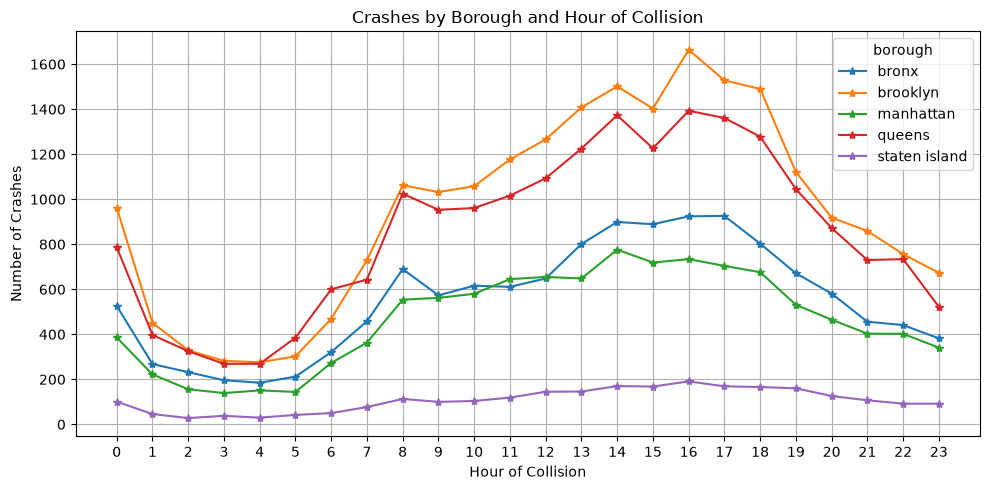

In [152]:
borough_hourly_analysis_pivot.plot(figsize=(10,5),marker="*")
plt.title("Crashes by Borough and Hour of Collision")
plt.xlabel("Hour of Collision")
plt.ylabel("Number of Crashes")
plt.ticklabel_format(style='plain', axis='y')
plt.xticks(borough_hourly_analysis_pivot["hour_of_collision"])
plt.grid(True)
plt.tight_layout()
plt.show()    

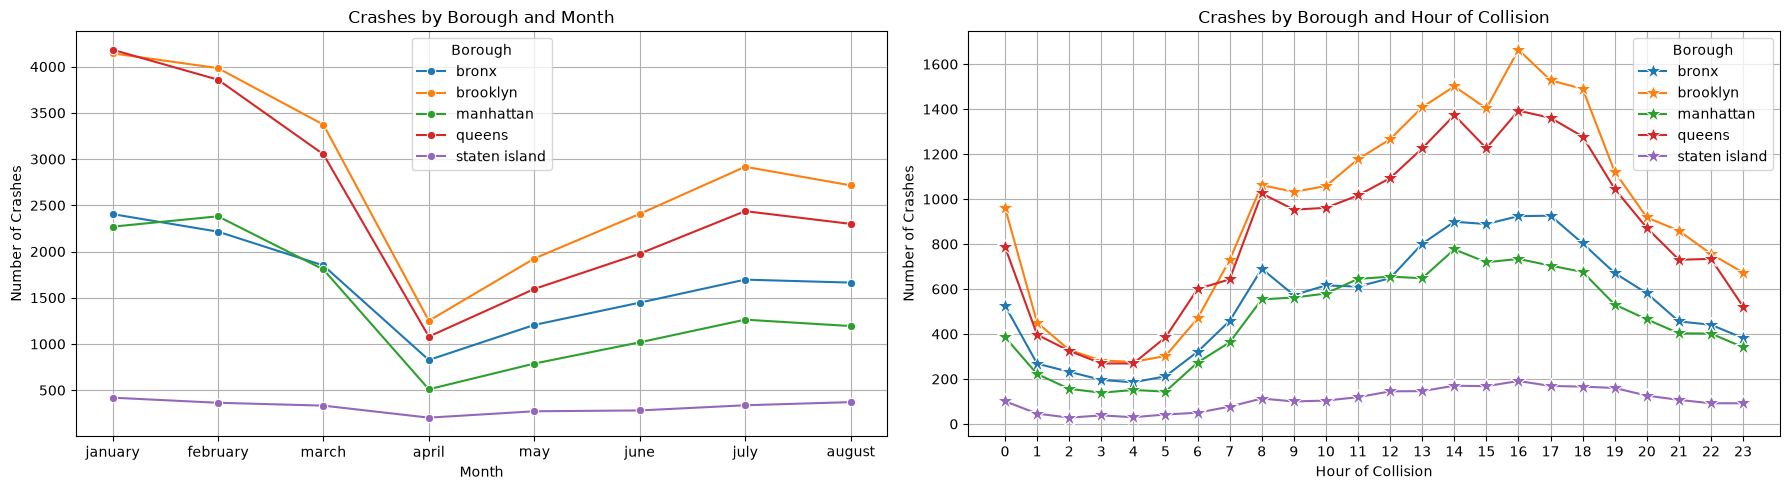

In [153]:
# Wide -> long for seaborn
monthly_long = borough_analysis_pivot.melt(
    id_vars="month", var_name="Borough", value_name="Crashes"
)
hourly_long = borough_hourly_analysis_pivot.melt(
    id_vars="hour_of_collision", var_name="Borough", value_name="Crashes"
)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Left: crashes by month
sns.lineplot(
    data=monthly_long, x="month", y="Crashes", hue="Borough",
    marker="o", ax=axes[0]
)
axes[0].set_title("Crashes by Borough and Month")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Number of Crashes")
axes[0].ticklabel_format(style="plain", axis="y")
axes[0].grid(True)

# Right: crashes by hour
sns.lineplot(
    data=hourly_long, x="hour_of_collision", y="Crashes", hue="Borough",
    marker="*", markersize=12, ax=axes[1]
)
axes[1].set_title("Crashes by Borough and Hour of Collision")
axes[1].set_xlabel("Hour of Collision")
axes[1].set_ylabel("Number of Crashes")
axes[1].ticklabel_format(style="plain", axis="y")
axes[1].set_xticks(borough_hourly_analysis_pivot["hour_of_collision"])
axes[1].grid(True)

plt.tight_layout()
plt.savefig("../images/borough_crashes_analysis.png", dpi=300, bbox_inches="tight")
plt.show()

In [154]:
for borough in borough_analysis["borough"]:
    subset = df[df["borough"] == borough]
    print(f"\n-- {borough.title()} --")
    print(subset["contributing factor vehicle 1"].value_counts().head())


-- Brooklyn --
contributing factor vehicle 1
unspecified                       6662
driver inattention/distraction    5644
failure to yield right-of-way     1569
following too closely             1303
passing too closely                912
Name: count, dtype: int64

-- Queens --
contributing factor vehicle 1
driver inattention/distraction    5739
unspecified                       4651
failure to yield right-of-way     1687
following too closely             1601
backing unsafely                   886
Name: count, dtype: int64

-- Bronx --
contributing factor vehicle 1
unspecified                       4394
driver inattention/distraction    2687
following too closely              670
failure to yield right-of-way      636
other vehicular                    569
Name: count, dtype: int64

-- Manhattan --
contributing factor vehicle 1
driver inattention/distraction    3184
unspecified                       2316
following too closely              755
passing or lane usage improper     570
f

In [155]:
borough_analysis["people_killed"].sum()

np.int64(130)

In [156]:
#check it teh row has a longitude and latitude
has_long_lat = df["longitude"].notna() & df["longitude"].notna()

# if it has a longitude and latitude and its co ordinates lay within the nyc box so anything outside dont consider
valid = (has_long_lat
         & df["latitude"].between(40.49, 40.92)
         & df["longitude"].between(-74.27, -73.69))

# check number that has both long and lat, then ones that are valid to use , and ones we cant use
print(has_long_lat.sum(),valid.sum(),len(df) - valid.sum())

68935 68872 6009


In [157]:
# weighted crash severity index
W_PDO, W_INJ, W_FATAL = 1, 10, 100   # severity scoring
df["severity"] = (W_PDO
                  + W_INJ * df["number of persons injured"]
                  + W_FATAL * df["number of persons killed"])

In [158]:
g_plane = gdp.GeoDataFrame(
    df[valid],
    geometry=gdp.points_from_xy(df.loc[valid,"longitude"],df.loc[valid,"latitude"]),
    crs=4326 # tells pandas this are gps degress
).to_crs(2263) # converts to the nyc plane units are feets

In [159]:
xy = np.c_[g_plane.geometry.x, g_plane.geometry.y]
g_plane["cluster"] = DBSCAN(eps=300, min_samples=15).fit_predict(xy)

In [160]:
def top(s): return s.dropna().mode().iloc[0] if s.notna().any() else None

In [161]:
hotspot = (g_plane[g_plane.cluster >= 1].groupby("cluster").agg(
    crashes = ("collision_id","count"),
    killed = ("number of persons killed", "sum"),
    injured = ("number of persons injured","sum"),   
    severity = ("severity","sum"),
    borough = ("borough",top),
    on_street=("on street name", top),
    cross_street=("cross street name", top)
).reset_index().sort_values(by="severity",ascending=False))
hotspot.head(10)

,cluster,crashes,killed,injured,severity,borough,on_street,cross_street
160,161,290,0,136,1650,bronx,cross bronx expy,cross bronx expressway
24,25,155,0,77,925,bronx,bruckner boulevard,bruckner boulevard
70,71,174,0,66,834,brooklyn,pennsylvania avenue,pennsylvania avenue
30,31,154,1,46,714,manhattan,canal street,canal street
129,130,128,0,57,698,manhattan,delancey street,delancey street
5,6,115,1,48,695,bronx,west fordham road,major deegan expressway
52,53,127,0,55,677,brooklyn,atlantic avenue,eastern parkway
41,42,87,0,55,637,bronx,west fordham road,west fordham road
75,76,137,0,50,637,brooklyn,flatbush avenue,atlantic avenue
142,143,109,0,49,599,bronx,major deegan expressway,west 230 street


In [162]:
hotspot["killed"].sum()

np.int64(29)

In [163]:
hspt = df.groupby("on street name").agg(
    crashes = ("collision_id","count"),
    killed = ("number of persons killed", "sum"),
    injured = ("number of persons injured","sum")
).reset_index().sort_values(by="crashes",ascending=False)
hspt_head = hspt.head(10)
hspt.head(10)

,on street name,crashes,killed,injured
913,belt parkway,1245,1,692
2345,long island expressway,745,0,284
1029,brooklyn queens expressway,740,3,332
1784,fdr drive,729,1,323
2392,major deegan expressway,591,2,338
1006,broadway,584,1,251
1924,grand central pkwy,581,5,342
710,atlantic avenue,534,0,214
1285,cross bronx expy,526,1,250
1288,cross island parkway,512,4,219


In [164]:
hspt_head["on street name"].unique()

<ArrowStringArray>
[              'belt parkway',     'long island expressway',
 'brooklyn queens expressway',                  'fdr drive',
    'major deegan expressway',                   'broadway',
         'grand central pkwy',            'atlantic avenue',
           'cross bronx expy',       'cross island parkway']
Length: 10, dtype: str

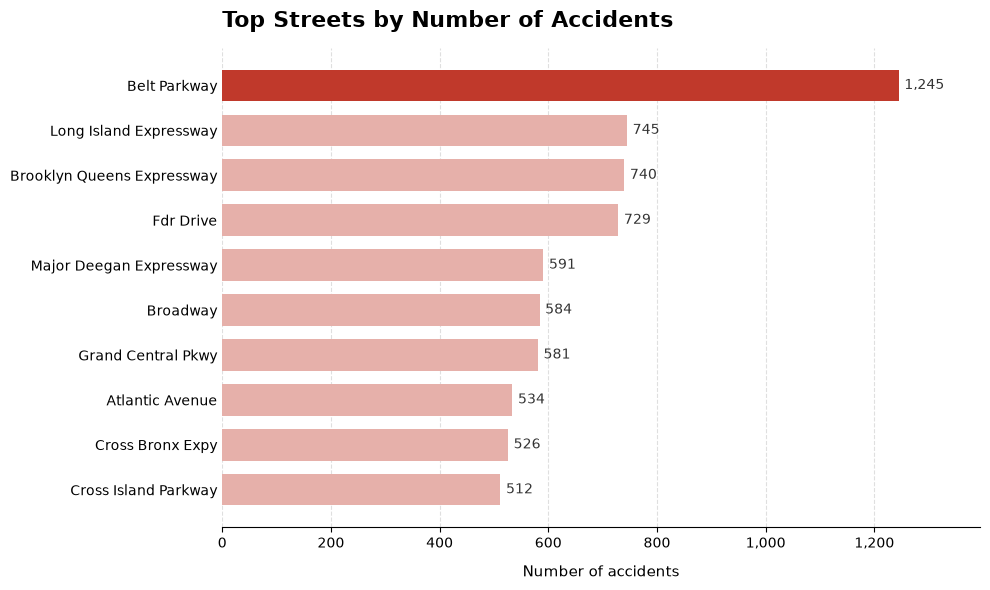

In [165]:

import matplotlib.ticker as mtick


data = hspt_head.sort_values("crashes", ascending=True)

# Highlight the top street, mute the rest
colors = ["#C0392B" if v == data["crashes"].max() else "#E6B0AA" for v in data["crashes"]]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(data["on street name"].str.title(), data["crashes"],
               color=colors, height=0.7)

# Value labels at the end of each bar
ax.bar_label(bars, labels=[f"{v:,.0f}" for v in data["crashes"]],
             padding=4, fontsize=10, color="#333333")

# Titles
ax.set_title("Top Streets by Number of Accidents",
             fontsize=16, fontweight="bold", loc="left", pad=15)
ax.set_xlabel("Number of accidents", fontsize=11, labelpad=10)
ax.set_ylabel("")  # street names are self-explanatory

# Clean axes
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.spines[["top", "right", "left"]].set_visible(False)
ax.tick_params(axis="y", length=0, labelsize=10)
ax.tick_params(axis="x", labelsize=10)

# Light vertical gridlines behind the bars
ax.xaxis.grid(True, linestyle="--", alpha=0.4)
ax.set_axisbelow(True)

# Breathing room for the labels
ax.set_xlim(0, data["crashes"].max() * 1.12)

plt.tight_layout()
plt.show()

In [166]:
for street in hspt_head["on street name"]:
    subset = df[df["on street name"] == street]
    print(f"\n--- {street.title()} ---")
    print(subset["contributing factor vehicle 1"].value_counts().head())


--- Belt Parkway ---
contributing factor vehicle 1
driver inattention/distraction    360
following too closely             206
unspecified                       190
reaction to uninvolved vehicle    102
unsafe speed                      102
Name: count, dtype: int64

--- Long Island Expressway ---
contributing factor vehicle 1
following too closely             234
driver inattention/distraction    217
unsafe lane changing               59
unspecified                        45
unsafe speed                       35
Name: count, dtype: int64

--- Brooklyn Queens Expressway ---
contributing factor vehicle 1
driver inattention/distraction    209
following too closely             193
unspecified                        84
unsafe lane changing               55
passing or lane usage improper     38
Name: count, dtype: int64

--- Fdr Drive ---
contributing factor vehicle 1
driver inattention/distraction    224
following too closely             143
unsafe speed                       63
unspecifi